# Naive Bayesian Classification: Article Titles

The naive Bayesian classifier is a relatively simple, but powerful supervised machine learning algorithm. In this notebook I create a Bayesian classifier from scratch to classify a news article based on its title. The dataset is from: https://www.kaggle.com/datasets/kotartemiy/topic-labeled-news-dataset

In [97]:
from collections import Counter
import math
import re
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('ggplot')

data = pd.read_csv("data/labelled_newscatcher_dataset.csv", header=0, sep=';')
del data['link']

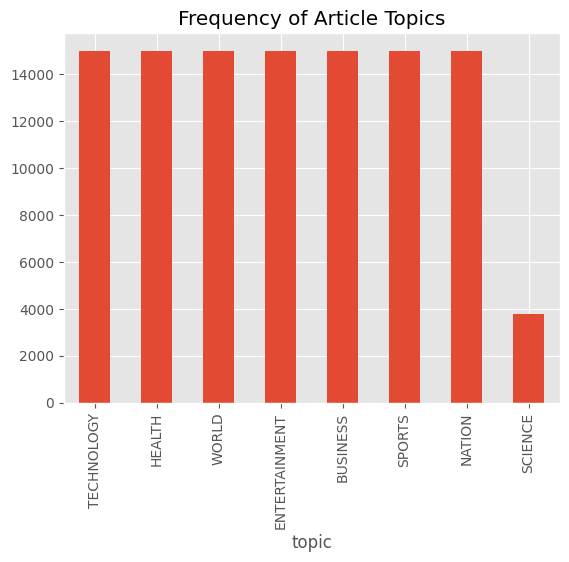

In [98]:
class_freq = data['topic'].value_counts()

class_freq.plot.bar()
plt.title("Frequency of Article Topics")
plt.show()

In [ ]:
# Data cleaning
data['title'] = (
    data['title']
    .str.lower()
    .str.replace(r'[.,?!/@#$%^&*(){}[]\-_=+\\|/><]', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Basic stop-word removal
stop_words_set = {
    "the", "and", "in", "of", "to", 
    "a", "is", "what", "how", "when",
    "where", "was", "why", "he", "she", "it",
}

# Pre-remove all stop words from the titles
data['title'] = data['title'].apply(
    lambda x: ' '.join([word for word in str(x).split() if word not in stop_words_set])
)

In [100]:
# Feature engineering
data['feature'] = data['title'].apply(
    lambda x: Counter(x.split())
)

In [101]:
# Split the data into training and test set
train_set = data.sample(frac=0.60, replace=False)
test_set  = data.drop(train_set.index)

In [102]:
# Extract the sentiment classes
sentiment_class = train_set['topic'].unique()

print(sentiment_class)

['NATION' 'ENTERTAINMENT' 'BUSINESS' 'TECHNOLOGY' 'WORLD' 'HEALTH'
 'SCIENCE' 'SPORTS']


#### Naive Bayesian Classifier

The Bayesian classifier uses conditional probability to compute the probabilitiy that an observation belongs to a specific class. It uses a prior assumption to compute the posterior probability.

One key assumption of the Bayesian classifier is that all features are independent. This example uses a Multinomial Bayesian classifier with a Laplace smooting factor.

Given an article title $A^*$,

$$
log \hat{P}(c_j | A^*) = logP(c_j) + \sum_i x_i logP(w_i | c_j) \newline
w_i = i^{th}\text{ word of the article title} \newline
c_j = j^{th}\text{ article title class}
$$

In [103]:
class BayesianMN:
    def __init__(self):
        self.p_class = {}
        self.class_counts = {}
        self.word_freq = Counter()
        
    def clean_title(self, title):
        """ Clean the article title. """
        
        title = title.lower()
        title = re.sub(r'[.,?!/@#$%^&*(){}\[\]\-_=+\\|/><]', '', title)
        title = re.sub(r'\s+', ' ', title)
        title = title.strip().split()
        
        return title
    
    def train(self, data, class_col):
        """
        Train the classifier by computing:
        - P(class) probability that a class occurs
        - P(word) probability that a word occurs
        - P(word | class) conditional probability that a word occurs in
            a particular class.
        """
        
        N = len(data)
        
        # Compute P(class)
        topic_counts = data[class_col].value_counts()
        self.p_class = (topic_counts / N).to_dict()
        
        for topic in self.p_class.keys():
            topic_words = data[data[class_col] == topic]['title'].str.cat(sep=' ')
            topic_words = self.clean_title(topic_words)
            
            word_freqs = Counter(topic_words)
            self.class_counts[topic] = word_freqs

            self.word_freq += word_freqs

    def predict(self, article_title):
        """ Compute the log probability P(article_title)=topic. """
        
        article_title = self.clean_title(article_title)
        feature_vector = Counter(article_title)
        
        class_scores = {}

        vocabulary_size = len(self.word_freq)

        for topic, p_topic in self.p_class.items():
            log_prob = math.log(p_topic)
            topic_total_words = sum(self.class_counts[topic].values())

            for word, count in feature_vector.items():
                word_count = self.class_counts[topic].get(word, 0)

                # Laplace smoothing
                p_word = (word_count + 1) / (
                    topic_total_words + vocabulary_size
                )
                log_prob += count * math.log(p_word)

            class_scores[topic] = log_prob

        return class_scores

In [104]:
classifier = BayesianMN()
classifier.train(train_set, 'topic')

In [105]:
# Test classifier's accuracy
results = [] # 1=success, 0=failure

for i in range(len(test_set)):
    probs = classifier.predict(test_set['title'].iloc[i])
    
    topic = max(probs, key=probs.get)
    results.append(int(topic == test_set['topic'].iloc[i]))

# Accuracy
print(f"Classifier Accuracy: {100 * (sum(results)/len(results)):.4f}%")

Classifier Accuracy: 78.0418%


In [106]:
test_title = "Trump meets Xi in China to discuss future of economic relations."

prediction = classifier.predict(test_title)

topic = max(prediction, key=prediction.get)
print(topic)

WORLD
